In [1]:
import pandas as pd

data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')
data.head()

/var/folders/wm/8p_6xrq1489c_g4rxgqr8nq00000gn/T/ipykernel_85418/129337520.py:3: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,107,F,White,Not Span/Hispanic,...,Major,Major,Medical,Medicaid,NaN,NaN,NaN,Y,"51,514.62","7,552.54"
1,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,M,Black/African American,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"25,370.86","3,469.55"
2,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Medical,Medicaid,NaN,NaN,NaN,N,"23,876.78","6,180.33"
3,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,100,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"43,319.05","12,588.93"
4,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,M,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,"40,266.23","10,355.99"


In [2]:
import json

with open("../data/data_info.json", "r") as f:
    data_info = json.load(f)

In [3]:
# Handle missing data and changing column type
for col_name, info in data_info.items():
    print(col_name)
    if info["type"] == "int64":
        if col_name == "Zip Code - 3 digits":
            data[col_name] = data[col_name].replace("OOS", 000)
            data[col_name] = data[col_name].fillna(000)
        if col_name == "Length of Stay":
            data[col_name] = data[col_name].replace("120 +", 121)
        if col_name == "Birth Weight":
            data[col_name] = data[col_name].replace("UNKN", -1)
            data[col_name] = data[col_name].fillna(-1)
        else:
            data[col_name] = data[col_name].fillna(-1)

        data[col_name] = pd.to_numeric(data[col_name]).astype('int')

    elif info["type"] == "str":
        data[col_name] = data[col_name].fillna("Unknown")
        data[col_name] = data[col_name].astype(str)

    elif info["type"] == "float64":
        data[col_name] = data[col_name].str.replace(',', '')
        data[col_name] = pd.to_numeric(data[col_name]).astype('float')


Hospital Service Area
Hospital County
Operating Certificate Number
Permanent Facility Id
Facility Name
Age Group
Zip Code - 3 digits
Gender
Race
Ethnicity
Length of Stay
Type of Admission
Patient Disposition
Discharge Year
CCSR Diagnosis Code
CCSR Diagnosis Description
CCSR Procedure Code
CCSR Procedure Description
APR DRG Code
APR DRG Description
APR MDC Code
APR MDC Description
APR Severity of Illness Code
APR Severity of Illness Description
APR Risk of Mortality
APR Medical Surgical Description
Payment Typology 1
Payment Typology 2
Payment Typology 3
Birth Weight
Emergency Department Indicator
Total Charges
Total Costs


In [4]:
# Identify categorical columns and convert them to categories
categorical_columns = []
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].astype('category')

In [5]:
X = data.drop(columns=['Total Costs', ])
y = data['Total Costs']

In [6]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import numpy as np
from sklearn.preprocessing import LabelEncoder


# LGBMRegressor

In [ ]:
import lightgbm as lgb
y_train = np.nan_to_num(y_train, nan=0.0, posinf=1e10, neginf=-1e10)

lgb_model = lgb.LGBMRegressor(objective="regression", metric='rmse', error_score='raise', random_state=21)

param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [-1, 5, 7],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_cv = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    error_score='raise'
)

grid_cv.fit(X_train, y_train)
best_lgb_model = grid_cv.best_estimator_
print("Best MSE (CV):", -grid_cv.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Warning] Unknown parameter: error_score
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: error_score
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2335
[LightGBM] [Info] Number of data points in the train set: 29731, number of used features: 31
[LightGBM] [Info] Start training from score 28287.257685
Best MSE (CV): 368435172.84524506


In [ ]:
# Predict and evaluate
y_pred = best_lgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

[LightGBM] [Warning] Unknown parameter: error_score
MAE: 3002.38
MSE: 260405138.47
R²: 0.90


In [ ]:
joblib.dump(best_lgb_model, "../models/lgb_best_model.pkl")

['../models/lgb_model.pkl']

## Calculate Variance for Best Model

In [15]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import lightgbm as lgb
import time 

y_train = np.nan_to_num(y_train, nan=0.0, posinf=1e10, neginf=-1e10)

lgb_model = lgb.LGBMRegressor(objective="regression",
                                metric='rmse',
                                error_score='raise',
                                random_state=21,
                                n_estimators=1000, 
                                max_depth=-1, 
                                learning_rate=0.1, 
                                num_leaves=63)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores, rmse_scores, r2_scores, time_per_sample = [], [], [], []

for train_idx, val_idx in cv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    lgb_model.fit(X_tr, y_tr)

    start_time = time.perf_counter()
    y_pred = lgb_model.predict(X_val)
    end_time = time.perf_counter()

    elapsed_time = end_time - start_time
    avg_time_per_sample = elapsed_time / len(X_val)
    time_per_sample.append(avg_time_per_sample)

    mae_scores.append(mean_absolute_error(y_val, y_pred))
    rmse_scores.append(mean_squared_error(y_val, y_pred, squared=False))  # RMSE
    r2_scores.append(r2_score(y_val, y_pred))

print(f"MAE:  {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")
print(f"RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")
print(f"R²:   {np.mean(r2_scores):.2f} ± {np.std(r2_scores):.2f}")
print(f"Avg time per sample: {np.mean(time_per_sample)*1000:.6f} ms ± {np.std(time_per_sample)*1000:.6f} ms")



[LightGBM] [Warning] Unknown parameter: error_score
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: error_score
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091335 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2871
[LightGBM] [Info] Number of data points in the train set: 1346196, number of used features: 31
[LightGBM] [Info] Start training from score 23431.300632
[LightGBM] [Warning] Unknown parameter: error_score
[LightGBM] [Warning] Unknown parameter: error_score
[LightGBM] [Warning] Categorical features with more bins than the con

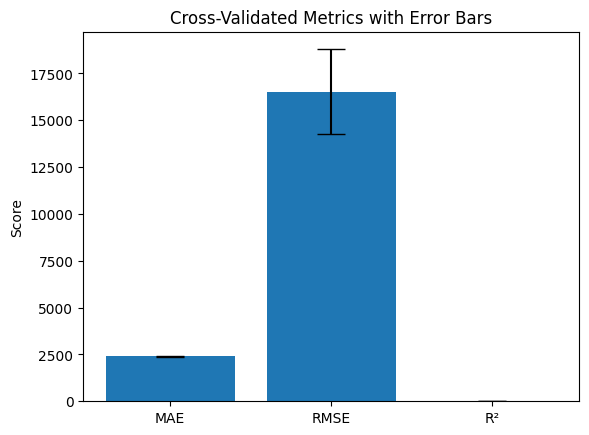

In [14]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R²']
means = [np.mean(mae_scores), np.mean(rmse_scores), np.mean(r2_scores)]
stds = [np.std(mae_scores), np.std(rmse_scores), np.std(r2_scores)]

plt.bar(metrics, means, yerr=stds, capsize=10)
plt.ylabel("Score")
plt.title("Cross-Validated Metrics with Error Bars")
plt.show()

# XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(objective='reg:squarederror', enable_categorical=True, seed = 21)

param_grid = {
    'n_estimators': [100, 200, 1000],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 10]
}


cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_cv = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_cv.fit(X_train, y_train)
best_xgboost_model = grid_cv.best_estimator_
print("Best MSE (CV):", -grid_cv.best_score_)



Fitting 5 folds for each of 1 candidates, totalling 144 fits
Best MSE (CV): 472518868.1205702


In [ ]:
# Predict and evaluate
y_pred = best_xgboost_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = (mean_squared_error(y_test, y_pred))**0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 2361.00
MSE: 14971.86
R²: 0.90


In [ ]:
joblib.dump(best_xgboost_model, "../models/best_xgb_model.pkl")

['../models/xgb_model.pkl']

## Calculate Variance for Best Model

In [19]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor
import time 

y_train = np.nan_to_num(y_train, nan=0.0, posinf=1e10, neginf=-1e10)

xgb_model = XGBRegressor(objective='reg:squarederror',
                                metric='rmse',
                                error_score='raise',
                                random_state=42,
                                n_estimators=1000, 
                                max_depth=6, 
                                learning_rate=0.3, 
                                sub_sample=1.0,
                                enable_categorical=True)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores, rmse_scores, r2_scores, time_per_sample = [], [], [], []

for train_idx, val_idx in cv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    xgb_model.fit(X_tr, y_tr)

    start_time = time.perf_counter()
    y_pred = xgb_model.predict(X_val)
    end_time = time.perf_counter()

    elapsed_time = end_time - start_time
    avg_time_per_sample = elapsed_time / len(X_val)
    time_per_sample.append(avg_time_per_sample)

    mae_scores.append(mean_absolute_error(y_val, y_pred))
    rmse_scores.append(mean_squared_error(y_val, y_pred, squared=False))  # RMSE
    r2_scores.append(r2_score(y_val, y_pred))

print(f"MAE:  {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")
print(f"RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")
print(f"R²:   {np.mean(r2_scores):.2f} ± {np.std(r2_scores):.2f}")
print(f"Avg time per sample: {np.mean(time_per_sample)*1000:.6f} ms ± {np.std(time_per_sample)*1000:.6f} ms")



/Users/sayeh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [17:27:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "error_score", "metric", "sub_sample" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sayeh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [17:29:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "error_score", "metric", "sub_sample" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sayeh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [17:30:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "error_score", "metric", "sub_sample" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sayeh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [17:32:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "error

MAE:  2415.26 ± 19.73
RMSE: 17801.29 ± 2461.50
R²:   0.87 ± 0.03
Avg time per sample: 0.012821 ms ± 0.000701 ms


# CatBoost

In [ ]:
from catboost import CatBoostRegressor

catb_model = CatBoostRegressor()

catb_model.fit(
    X_train,
    y_train,
    cat_features=[col for col in data.columns if data[col].dtype == "category"],
)

Learning rate set to 0.132401
0:	learn: 46110.7021864	total: 871ms	remaining: 14m 30s
1:	learn: 42695.0190115	total: 1.95s	remaining: 16m 12s
2:	learn: 39874.7724768	total: 2.92s	remaining: 16m 9s
3:	learn: 37402.4516040	total: 3.78s	remaining: 15m 41s
4:	learn: 35388.0736504	total: 4.59s	remaining: 15m 14s
5:	learn: 33679.2912503	total: 5.24s	remaining: 14m 27s
6:	learn: 32265.2363891	total: 5.88s	remaining: 13m 54s
7:	learn: 31090.4066337	total: 6.75s	remaining: 13m 57s
8:	learn: 30125.8483856	total: 7.4s	remaining: 13m 34s
9:	learn: 29221.9225245	total: 8.17s	remaining: 13m 28s
10:	learn: 28475.2764391	total: 8.84s	remaining: 13m 14s
11:	learn: 27736.3741329	total: 9.52s	remaining: 13m 3s
12:	learn: 27098.4742849	total: 10.3s	remaining: 13m
13:	learn: 26581.6694887	total: 10.9s	remaining: 12m 48s
14:	learn: 26123.5692219	total: 11.5s	remaining: 12m 35s
15:	learn: 25789.5543955	total: 12.2s	remaining: 12m 31s
16:	learn: 25474.2647391	total: 12.9s	remaining: 12m 27s
17:	learn: 25016.1

In [ ]:
y_pred = catb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 3119.32
MSE: 203795454.37
R²: 0.92


In [ ]:
joblib.dump(catb_model, "../models/catb_model.pkl")

['../models/catb_model.pkl']

# AdaBoost

In [ ]:
data_temp = data.copy()

for col in data_temp.select_dtypes(include='category').columns:
    print(col)
    le = LabelEncoder()
    data_temp[col] = le.fit_transform(data_temp[col].astype(str))

Hospital Service Area
Hospital County
Facility Name
Age Group
Gender
Race
Ethnicity
Type of Admission
Patient Disposition
CCSR Diagnosis Code
CCSR Diagnosis Description
CCSR Procedure Code
CCSR Procedure Description
APR DRG Description
APR MDC Description
APR Severity of Illness Code
APR Severity of Illness Description
APR Risk of Mortality
APR Medical Surgical Description
Payment Typology 1
Payment Typology 2
Payment Typology 3
Emergency Department Indicator


In [ ]:
X = data_temp.drop(columns=['Total Costs'])
y = data_temp['Total Costs']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                  learning_rate=0.1, n_estimators=100, random_state=42)

In [ ]:
# Predict and evaluate
y_pred = ada_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 9566.88
MSE: 581509263.58
R²: 0.76


In [ ]:
joblib.dump(ada_model, "../models/adab_model.pkl")

# Tabnet

In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.preprocessing import LabelEncoder
import torch


data_temp = data.copy()

cat_cols = [col for col in data_temp.columns if data_temp[col].dtype == "category"]
cat_idxs = [i for i, col in enumerate(data_temp.columns) if data_temp[col].dtype == "category"]

# Encode categorical variables using LabelEncoder (TabNet needs int-coded categories)
for col in cat_cols:
    le = LabelEncoder()
    data_temp[col] = le.fit_transform(data_temp[col].astype(str))


X = data_temp.drop(columns=['Total Costs', ])
y = data_temp['Total Costs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

In [ ]:
tabnet = TabNetRegressor(
    cat_idxs=cat_idxs,
    cat_dims=[len(data_temp[col].unique()) for col in cat_cols],
    cat_emb_dim=3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={'step_size': 10, 'gamma': 0.95},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10
)

tabnet.fit(
    X_train=X_train_np,
    y_train=y_train_np,
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128
)

In [ ]:
# Predict and evaluate
y_pred = tabnet.predict(X_test_np)

mae = mean_absolute_error(y_test_np, y_pred)
mse = mean_squared_error(y_test_np, y_pred)
r2 = r2_score(y_test_np, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import torch


data['Total Cost'] = data['Total Cost'].replace('[\$,]', '', regex=True).astype(float)

data = data.dropna(subset=['Total Cost'])

target = 'Total Cost'
features = [col for col in data.columns if col not in ['Total Charges', 'Total Cost']]

cat_cols = data[features].select_dtypes(include='object').columns.tolist()
num_cols = data[features].select_dtypes(include=['int', 'float']).columns.tolist()

# Encode categorical variables using LabelEncoder (TabNet needs int-coded categories)
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

imputer = SimpleImputer(strategy='most_frequent')
data[features] = imputer.fit_transform(data[features])

X_train, X_test, y_train, y_test = train_test_split(
    data[features], data[target], test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

cat_idxs = [i for i, col in enumerate(features) if col in cat_cols]

tabnet = TabNetRegressor(
    cat_idxs=cat_idxs,
    cat_dims=[len(data[col].unique()) for col in cat_cols],
    cat_emb_dim=3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={'step_size': 10, 'gamma': 0.95},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10
)

tabnet.fit(
    X_train=X_train_np,
    y_train=y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128
)

# Predict and evaluate
y_pred = tabnet.predict(X_test_np)

mae = mean_absolute_error(y_test_np, y_pred)
mse = mean_squared_error(y_test_np, y_pred)
r2 = r2_score(y_test_np, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

In [ ]:
mae_tabnet = mean_absolute_error(y_test_np, y_pred)
print(mae_tabnet)

20310.872770479134


# TabM

In [ ]:
!git clone https://github.com/yandex-research/tabm
!pip install rtdl_num_embeddings

Cloning into 'tabm'...
remote: Enumerating objects: 74591, done.
remote: Counting objects: 100% (7046/7046), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 74591 (delta 7026), reused 6977 (delta 6976), pack-reused 67545 (from 2)
Receiving objects: 100% (74591/74591), 17.37 MiB | 11.54 MiB/s, done.
Resolving deltas: 100% (45911/45911), done.
Updating files: 100% (60179/60179), done.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [ ]:
import sklearn

cont_cols = X.select_dtypes(exclude=['category']).columns
X_cont = X[cont_cols].to_numpy(dtype='float32')

cat_cols = X.select_dtypes(include=['category']).columns
X_cat = X[cat_cols].apply(lambda s: s.cat.codes).to_numpy(dtype='int64')

y = data['Total Costs'].to_numpy()

indices = list(range(len(y)))

train_indices, test_indices = sklearn.model_selection.train_test_split(indices, test_size=0.2, random_state=42)
train_indices, val_indices = sklearn.model_selection.train_test_split(train_indices, test_size=0.2, random_state=42)

data = {
    'train': {'x_cont': X_cont[train_indices], 'x_cat': X_cat[train_indices], 'y': y[train_indices]},
    'val': {'x_cont': X_cont[val_indices], 'x_cat': X_cat[val_indices], 'y': y[val_indices]},
    'test': {'x_cont': X_cont[test_indices], 'x_cat': X_cat[test_indices], 'y': y[test_indices]},
}

**The code after this is taken from the official TabM example.**

In [ ]:
import numpy as np

X_cont_train_numpy = data['train']['x_cont']
noise = (
    np.random.default_rng(0)
    .normal(0.0, 1e-5, X_cont_train_numpy.shape)
    .astype(X_cont_train_numpy.dtype)
)
preprocessing = sklearn.preprocessing.QuantileTransformer(
    n_quantiles=max(min(len(train_indices) // 30, 1000), 10),
    output_distribution='normal',
    subsample=10**9,
).fit(X_cont_train_numpy + noise)

del X_cont_train_numpy

for part in data:
    data[part]['x_cont'] = preprocessing.transform(data[part]['x_cont'])

Y_train = data['train']['y'].copy()
y_mean = Y_train.mean().item()
y_std = Y_train.std().item()
Y_train = (Y_train - y_mean) / y_std

In [ ]:
import torch

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

data = {
    part: {k: torch.as_tensor(v, device=device) for k, v in data[part].items()}
    for part in data
}
Y_train = torch.as_tensor(Y_train, device=device)

for part in data:
    data[part]['y'] = data[part]['y'].float()
Y_train = Y_train.float()

amp_dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    else torch.float16
    if torch.cuda.is_available()
    else None
)
amp_enabled = False and amp_dtype is not None
grad_scaler = torch.cuda.amp.GradScaler() if amp_dtype is torch.float16 else None

compile_model = False

print(
    f'Device:        {device.type.upper()}'
    f'\nAMP:           {amp_enabled} (dtype: {amp_dtype})'
    f'\ntorch.compile: {compile_model}'
)

In [ ]:
from tabm.tabm_reference import Model, make_parameter_groups

arch_type = 'tabm'
bins = None


n_cont_features = X_cont.shape[1]

per_col_max = X_cat.max(axis=0)
cat_cardinalities = (per_col_max + 1).tolist()

model = Model(
    n_num_features=n_cont_features,
    cat_cardinalities=cat_cardinalities,
    n_classes=None,
    backbone={
        'type': 'MLP',
        'n_blocks': 3 if bins is None else 2,
        'd_block': 512,
        'dropout': 0.1,
    },
    bins=bins,
    num_embeddings=(
        None
        if bins is None
        else {
            'type': 'PiecewiseLinearEmbeddings',
            'd_embedding': 16,
            'activation': False,
            'version': 'B',
        }
    ),
    arch_type=arch_type,
    k=32,
    share_training_batches=True,
).to(device)
optimizer = torch.optim.AdamW(make_parameter_groups(model), lr=2e-3, weight_decay=3e-4)

if compile_model:
    # NOTE
    # `torch.compile` is intentionally called without the `mode` argument
    # (mode="reduce-overhead" caused issues during training with torch==2.0.1).
    model = torch.compile(model)
    evaluation_mode = torch.no_grad
else:
    evaluation_mode = torch.inference_mode

In [ ]:
import torch.nn.functional as F


@torch.autocast(device.type, enabled=amp_enabled, dtype=amp_dtype)  # type: ignore[code]
def apply_model(part: str, idx: torch.Tensor) -> torch.Tensor:
    return (
        model(
            data[part]['x_cont'][idx],
            data[part]['x_cat'][idx] if 'x_cat' in data[part] else None,
        )
        .squeeze(-1)
        .float()
    )


base_loss_fn = F.mse_loss


def loss_fn(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    k = y_pred.shape[-1]
    return base_loss_fn(
        y_pred.flatten(0, 1),
        y_true.repeat_interleave(k) if model.share_training_batches else y_true,
    )


@evaluation_mode()
def evaluate(part: str) -> float:
    model.eval()

    # When using torch.compile, you may need to reduce the evaluation batch size.
    eval_batch_size = 8096
    y_pred: np.ndarray = (
        torch.cat(
            [
                apply_model(part, idx)
                for idx in torch.arange(len(data[part]['y']), device=device).split(
                    eval_batch_size
                )
            ]
        )
        .cpu()
        .numpy()
    )
    y_pred = y_pred * y_std + y_mean

    y_pred = y_pred.mean(1)

    y_true = data[part]['y'].cpu().numpy()
    score = (
        (sklearn.metrics.mean_squared_error(y_true, y_pred) ** 0.5)
    )
    return float(score)  # The higher -- the better.


print(f'Test score before training: {evaluate("test"):.4f}')

Test score before training: -49110.7952


In [3]:
! pip install optuna
import optuna
from sklearn.model_selection import KFold
import math
from tqdm import tqdm
import sklearn
import numpy as np
import torch
from tabm.tabm_reference import Model, make_parameter_groups

data = {}
model = None
n_epochs = 1_000_000_000
patience = 16

train_size = len(train_indices)
batch_size = 256
epoch_size = math.ceil(train_size / batch_size)
best = {
    'val': math.inf,
    'test': math.inf,
    'epoch': -1,
    'model': ''
}
# Early stopping: the training stops when
# there are more than `patience` consequtive bad updates.
patience = 16
remaining_patience = patience


def objective(trial):
    global train_indices, test_indices, X_cont, X_cat, y, data, model
    d_block = trial.suggest_categorical('d_block', [256, 512, 1024])
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (inner_train_idx, inner_val_idx) in enumerate(kf.split(train_indices)):
        train_indices = np.array(train_indices)
        train_fold_idx = train_indices[inner_train_idx]  # map back to full dataset
        val_fold_idx = train_indices[inner_val_idx]
        data = {
            'train': {'x_cont': X_cont[train_fold_idx], 'x_cat': X_cat[train_fold_idx], 'y': y[train_fold_idx]},
            'val': {'x_cont': X_cont[val_fold_idx], 'x_cat': X_cat[val_fold_idx], 'y': y[val_fold_idx]},
            'test': {'x_cont': X_cont[test_indices], 'x_cat': X_cat[test_indices], 'y': y[test_indices]}
        }
        X_cont_train_numpy = data['train']['x_cont']
        noise = (
            np.random.default_rng(0)
            .normal(0.0, 1e-5, X_cont_train_numpy.shape)
            .astype(X_cont_train_numpy.dtype)
        )
        preprocessing = sklearn.preprocessing.QuantileTransformer(
            n_quantiles=max(min(len(train_indices) // 30, 1000), 10),
            output_distribution='normal',
            subsample=10**9,
        ).fit(X_cont_train_numpy + noise)

        del X_cont_train_numpy

        for part in data:
            data[part]['x_cont'] = preprocessing.transform(data[part]['x_cont'])

        Y_train = data['train']['y'].astype('float32').copy()
        y_mean = Y_train.mean().item()
        y_std = Y_train.std().item()
        Y_train = (Y_train - y_mean) / y_std


        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        data = {
            part: {k: torch.as_tensor(v, device=device) for k, v in data[part].items()}
            for part in data
        }
        Y_train = torch.as_tensor(Y_train, device=device)

        for part in data:
            data[part]['y'] = data[part]['y'].float()
        Y_train = Y_train.float()

        amp_dtype = (
            torch.bfloat16
            if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
            else torch.float16
            if torch.cuda.is_available()
            else None
        )
        amp_enabled = False and amp_dtype is not None
        grad_scaler = torch.cuda.amp.GradScaler() if amp_dtype is torch.float16 else None

        compile_model = False

        arch_type = 'tabm'
        bins = None


        n_cont_features = X_cont.shape[1]

        per_col_max = X_cat.max(axis=0)
        cat_cardinalities = (per_col_max + 1).tolist()

        model = Model(
            n_num_features=n_cont_features,
            cat_cardinalities=cat_cardinalities,
            n_classes=None,
            backbone={
                'type': 'MLP',
                'n_blocks': 3 if bins is None else 2,
                'd_block': d_block,
                'dropout': dropout,
            },
            bins=bins,
            num_embeddings=(
                None
                if bins is None
                else {
                    'type': 'PiecewiseLinearEmbeddings',
                    'd_embedding': 16,
                    'activation': False,
                    'version': 'B',
                }
            ),
            arch_type=arch_type,
            k=32,
            share_training_batches=True,
        ).to(device)
        optimizer = torch.optim.AdamW(make_parameter_groups(model), lr=lr, weight_decay=weight_decay)
        best_val_score = float("inf")

        if compile_model:
            # NOTE
            # `torch.compile` is intentionally called without the `mode` argument
            # (mode="reduce-overhead" caused issues during training with torch==2.0.1).
            model = torch.compile(model)
            evaluation_mode = torch.no_grad
        else:
            evaluation_mode = torch.inference_mode

        n_epochs = 1_000_000_000
        patience = 16

        train_size = len(train_fold_idx)
        batch_size = 256
        epoch_size = math.ceil(train_size / batch_size)
        best = {
            'val': math.inf,
            'test': math.inf,
            'epoch': -1,
        }
        # Early stopping: the training stops when
        # there are more than `patience` consequtive bad updates.
        patience = 16
        remaining_patience = patience

        for epoch in range(n_epochs):
            batches = (
                torch.randperm(train_size, device=device).split(batch_size)
                if model.share_training_batches
                else [
                    x.transpose(0, 1).flatten()
                    for x in torch.rand((model.k, train_size), device=device)
                    .argsort(dim=1)
                    .split(batch_size, dim=1)
                ]
            )
            for batch_idx in tqdm(batches, desc=f'Epoch {epoch}'):
                model.train()
                optimizer.zero_grad()
                loss = loss_fn(apply_model('train', batch_idx), Y_train[batch_idx])
                if grad_scaler is None:
                    loss.backward()
                    optimizer.step()
                else:
                    grad_scaler.scale(loss).backward()  # type: ignore
                    grad_scaler.step(optimizer)
                    grad_scaler.update()

            model.eval()
            val_score = evaluate('val', y_std, y_mean)
            val_score = evaluate('test', y_std, y_mean)

            if val_score < best_val_score:
                best = {'val': val_score, 'test': test_score, 'epoch': epoch, 'fold':fold}
                remaining_patience = patience
            else:
                remaining_patience -= 1

            if remaining_patience < 0:
                break

        cv_scores.append(best_val_score)
    mean_rmse = np.mean(cv_scores)
    if mean_rmse < best['val']:
        best['val'] = mean_rmse
        best['test'] = np.mean(test_score)
        torch.save(model.state_dict(), '../models/best_tabm_model.pth')


    return mean_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)
print("Best CV RMSE:", study.best_value)



Best CV RMSE: 13052.84
